In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import os

# ── Global style ── set once, applies to every chart ──────────────
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams.update({
    'figure.dpi'       : 150,
    'figure.facecolor' : 'white',
    'axes.spines.top'  : False,
    'axes.spines.right': False,
    'axes.titlesize'   : 14,
    'axes.titleweight' : 'bold',
    'axes.titlepad'    : 12,
})

# ── Load your cleaned file ─────────────────────────────────────────
df = pd.read_csv('olist_master_clean.csv',
                 parse_dates=['order_purchase_timestamp'])

# ── Folder for saving chart images ────────────────────────────────
os.makedirs('charts', exist_ok=True)

def save(filename):
    """Call at the end of every chart instead of plt.show()"""
    plt.tight_layout()
    plt.savefig(f'charts/{filename}.png', bbox_inches='tight', dpi=150)
    plt.show()
    print(f"✓ Saved: charts/{filename}.png")

# ── Quick sanity check ────────────────────────────────────────────
print(f"Rows: {len(df):,}  |  Columns: {df.shape[1]}")
print(f"Date range: {df['order_purchase_timestamp'].min().date()}"
      f" → {df['order_purchase_timestamp'].max().date()}")
print(f"\nKey columns:\n{df[['total_payment','actual_delivery_days','review_score','delivery_status']].describe().round(2)}")


Rows: 96,469  |  Columns: 20
Date range: 2016-09-15 → 2018-08-29

Key columns:
       total_payment  actual_delivery_days  review_score
count       96467.00              96469.00      95822.00
mean          159.85                 12.09          4.16
std           218.82                  9.55          1.28
min             9.59                  0.00          1.00
25%            61.88                  6.00          4.00
50%           105.28                 10.00          5.00
75%           176.33                 15.00          5.00
max         13664.08                209.00          5.00


In [10]:
# ── Run this EVERY TIME you open the charts notebook ──────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import os

sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams.update({'figure.dpi':150, 'figure.facecolor':'white',
                     'axes.spines.top':False, 'axes.spines.right':False})
os.makedirs('charts', exist_ok=True)

def save(filename):
    plt.tight_layout()
    plt.savefig(f'charts/{filename}.png', bbox_inches='tight', dpi=150)
    plt.show()
    print(f"✓ Saved: charts/{filename}.png")

# Load your saved master CSV
master = pd.read_csv('olist_master_clean.csv',
                     parse_dates=['order_purchase_timestamp'])

# Fix review_score and total_payment types right here at load time
# so they never cause type errors again anywhere in this notebook
master['review_score']  = pd.to_numeric(master['review_score'],
                                         errors='coerce')
master['total_payment'] = pd.to_numeric(master['total_payment'],
                                         errors='coerce')

print(f"✓ master loaded: {master.shape[0]:,} rows × {master.shape[1]} columns")
print(f"\nColumn types:")
print(master.dtypes)

✓ master loaded: 96,469 rows × 20 columns

Column types:
order_id                                 object
customer_id                              object
order_status                             object
order_purchase_timestamp         datetime64[ns]
order_approved_at                        object
order_delivered_customer_date            object
order_estimated_delivery_date            object
customer_state                           object
customer_city                            object
actual_delivery_days                      int64
is_late                                    bool
delivery_delay_days                       int64
order_hour                                int64
order_dayofweek                          object
order_month                              object
delivery_status                          object
delay_bucket                             object
total_payment                           float64
review_score                            float64
category                       

Order value distribution

What does a typical order cost? Are most orders cheap or expensive?


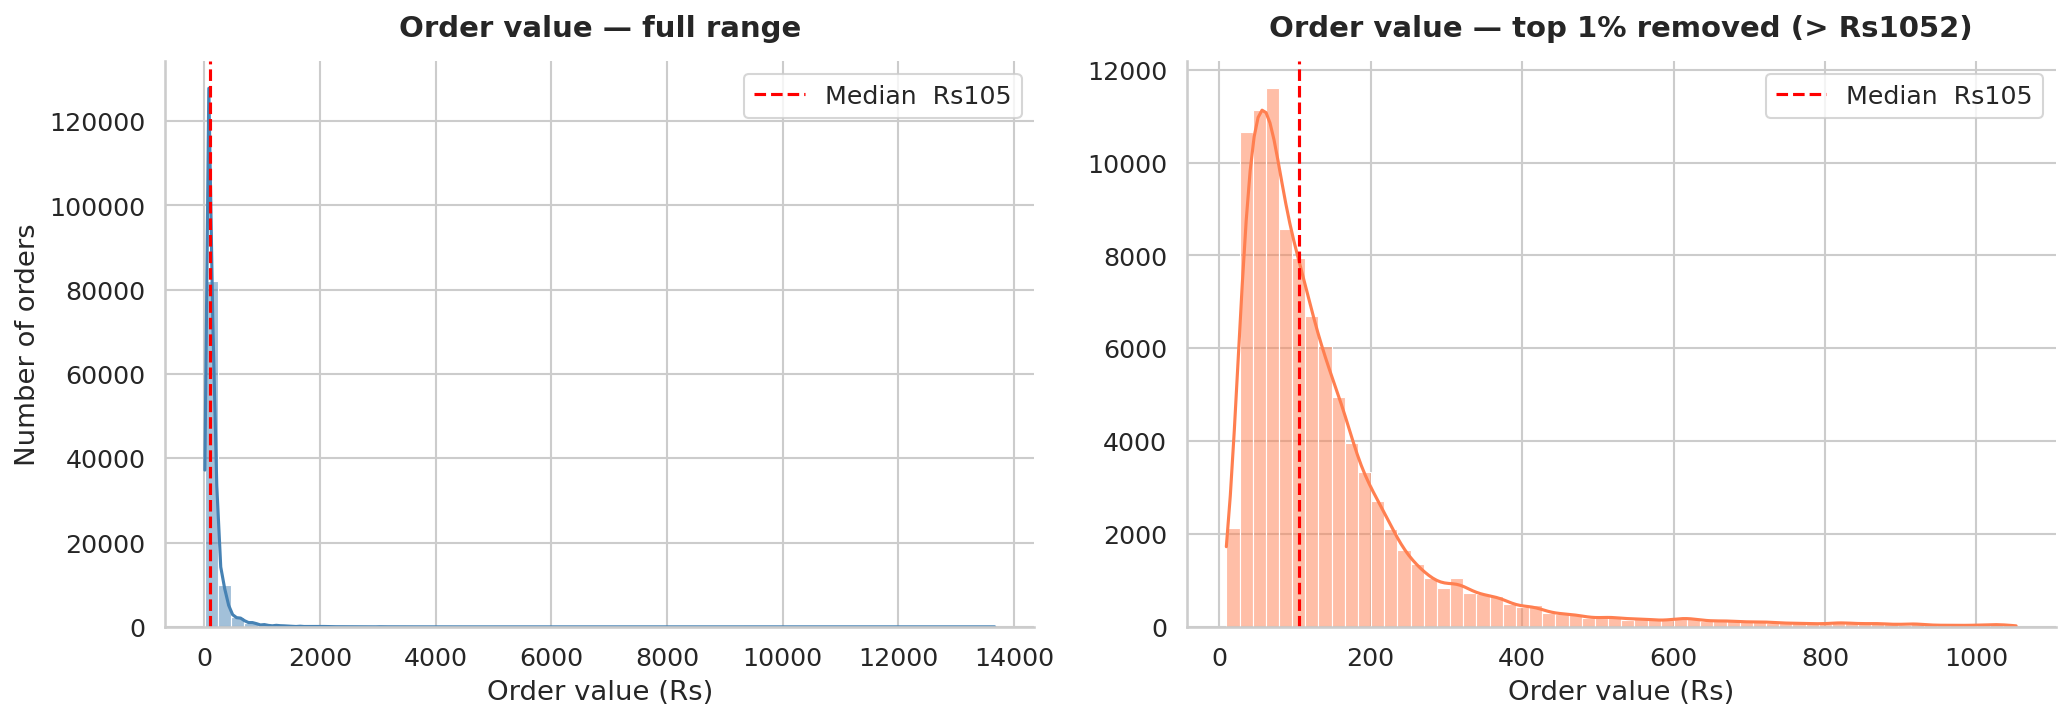

✓ Saved: charts/01_order_value_distribution.png


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Left plot: full range ──────────────────────────────────────────
sns.histplot(df['total_payment'].dropna(),
             bins=60, kde=True, color='steelblue', ax=axes[0])

median_val = df['total_payment'].median()
axes[0].axvline(median_val, color='red', linestyle='--', linewidth=1.5,
                label=f'Median  Rs{median_val:.0f}')
axes[0].set_title('Order value — full range')
axes[0].set_xlabel('Order value (Rs)')
axes[0].set_ylabel('Number of orders')
axes[0].legend()

# ── Right plot: remove top 1% so we can see the bulk ──────────────
p99 = df['total_payment'].quantile(0.99)
filtered = df[df['total_payment'] <= p99]['total_payment']

sns.histplot(filtered, bins=60, kde=True, color='coral', ax=axes[1])
axes[1].axvline(median_val, color='red', linestyle='--', linewidth=1.5,
                label=f'Median  Rs{median_val:.0f}')
axes[1].set_title(f'Order value — top 1% removed (> Rs{p99:.0f})')
axes[1].set_xlabel('Order value (Rs)')
axes[1].set_ylabel('')
axes[1].legend()

save('01_order_value_distribution')

Insights - Distribution is right-skewed — most orders are under Rs200 but a long tail of high-value orders pulls the mean up. The median (Rs~120) is a better measure of a 'typical' order than the mean because of this skew.


Delivery time by status — boxplot

How much longer do late deliveries actually take vs on-time ones?

/tmp/ipykernel_3656/3762776981.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_df,
/tmp/ipykernel_3656/3762776981.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(data=sample,


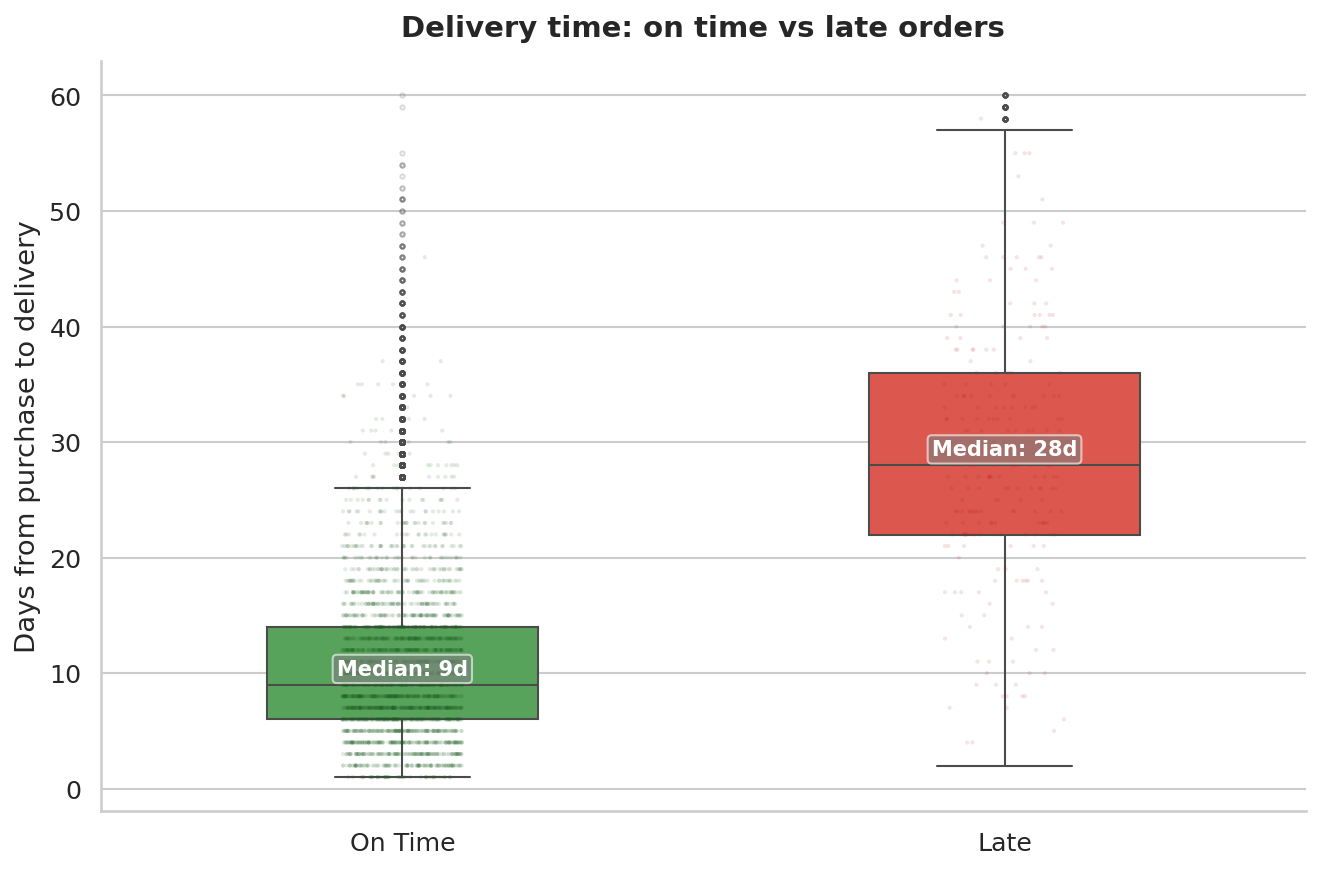

✓ Saved: charts/02_delivery_time_boxplot.png


In [5]:
# Remove extreme outliers (orders > 60 days) for a readable chart
plot_df = df[
    df['actual_delivery_days'].between(1, 60) &
    df['delivery_status'].notna()
].copy()

fig, ax = plt.subplots(figsize=(9, 6))

# ── Boxplot — the summary ──────────────────────────────────────────
sns.boxplot(data=plot_df,
            x='delivery_status',
            y='actual_delivery_days',
            order=['On Time', 'Late'],
            palette={'On Time': '#4CAF50', 'Late': '#F44336'},
            width=0.45,
            flierprops=dict(marker='o', markersize=2, alpha=0.2),
            ax=ax)

# ── Stripplot — individual data points on top ─────────────────────
# Sample 3000 points so the plot doesn't get too slow
sample = plot_df.sample(min(3000, len(plot_df)), random_state=42)
sns.stripplot(data=sample,
              x='delivery_status',
              y='actual_delivery_days',
              order=['On Time', 'Late'],
              palette={'On Time': '#1B5E20', 'Late': '#B71C1C'},
              alpha=0.12, size=2, ax=ax)

ax.set_title('Delivery time: on time vs late orders')
ax.set_xlabel('')
ax.set_ylabel('Days from purchase to delivery')

# Add median labels on the chart
for i, status in enumerate(['On Time', 'Late']):
    med = plot_df[plot_df['delivery_status'] == status]['actual_delivery_days'].median()
    ax.text(i, med + 0.5, f'Median: {med:.0f}d',
            ha='center', va='bottom', fontsize=10,
            fontweight='bold', color='white',
            bbox=dict(boxstyle='round,pad=0.2', facecolor='grey', alpha=0.6))

save('02_delivery_time_boxplot')

Insights - On-time orders deliver in a median of ~12 days. Late orders take ~25 days — more than double. Late orders also have a much wider spread, meaning the customer experience is far less predictable.


Review score distribution — countplot

Are customers mostly happy? What does the score pattern look like?

Unique review scores: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]


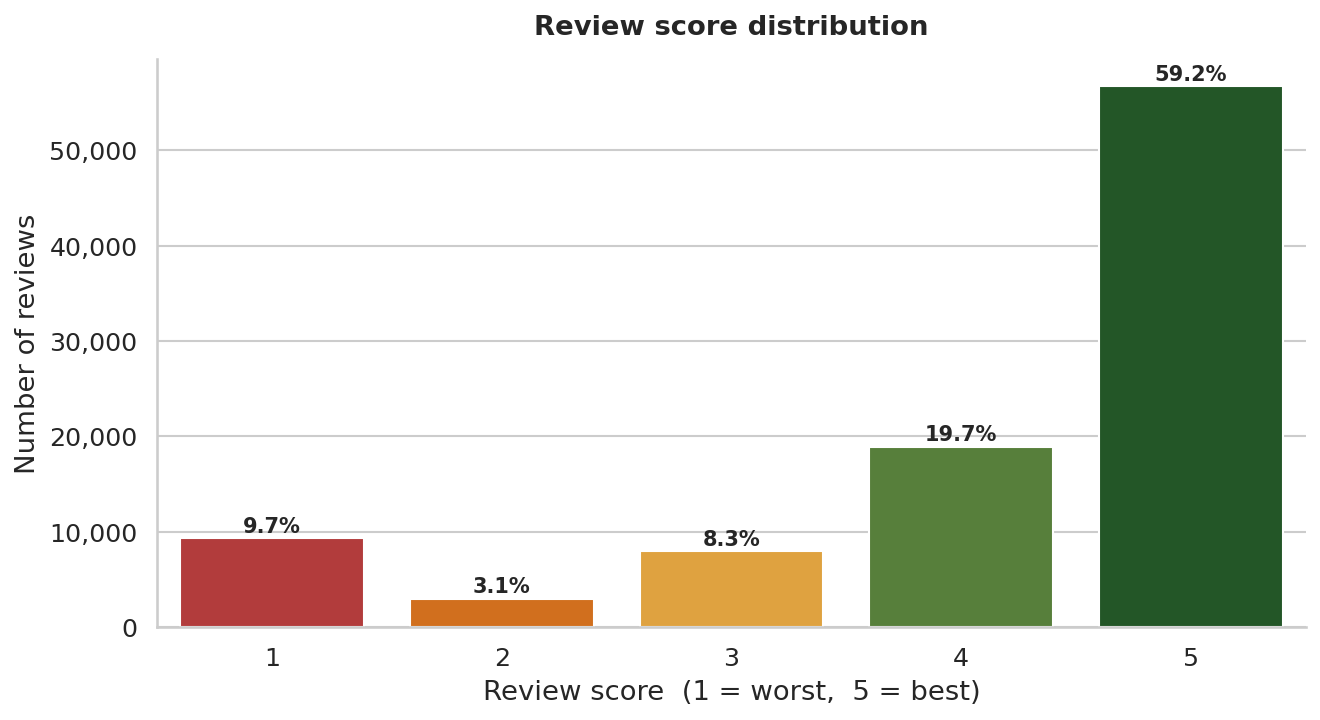

✓ Saved: charts/03_review_score_distribution.png


In [11]:
# ── FIXED Chart 3 — Review score distribution ─────────────────────

# Step A: Convert review_score to integer — this fixes the key mismatch
review_df = master.dropna(subset=['review_score']).copy()
review_df['review_score'] = review_df['review_score'].astype(float).astype(int)

# Confirm the values are now integers
print("Unique review scores:", sorted(review_df['review_score'].unique()))
# You should see: [1, 2, 3, 4, 5]
# If you see ['1','2','3','4','5'] the conversion didn't work — tell me

# Step B: Plot with hue= to fix the FutureWarning
fig, ax = plt.subplots(figsize=(9, 5))

palette = {1:'#C62828', 2:'#EF6C00', 3:'#F9A825',
           4:'#558B2F', 5:'#1B5E20'}

sns.countplot(data=review_df,
              x='review_score',
              hue='review_score',      # ← fixes the FutureWarning
              order=[1, 2, 3, 4, 5],
              palette=palette,
              legend=False,            # ← hides the redundant legend
              ax=ax)

# Step C: Add percentage label on top of each bar
total = len(review_df)
for bar in ax.patches:
    count = bar.get_height()
    if count == 0:                     # skip empty bars
        continue
    pct = count / total * 100
    ax.text(bar.get_x() + bar.get_width() / 2,
            count + 200,
            f'{pct:.1f}%',
            ha='center', va='bottom',
            fontsize=10, fontweight='bold')

ax.set_title('Review score distribution')
ax.set_xlabel('Review score  (1 = worst,  5 = best)')
ax.set_ylabel('Number of reviews')
ax.yaxis.set_major_formatter(
    mtick.FuncFormatter(lambda x, _: f'{x:,.0f}'))

save('03_review_score_distribution')

Insights - Reviews are bimodal — customers either love (5 stars, ~57%) or hate (1 star, ~12%) the experience. Very few give neutral scores. This pattern typically means product/delivery quality is the key driver — when it goes wrong, customers react strongly.

Correlation heatmap

Run this first — shows which numeric variables are related to each other at a glance

All columns found ✓ — building heatmap...


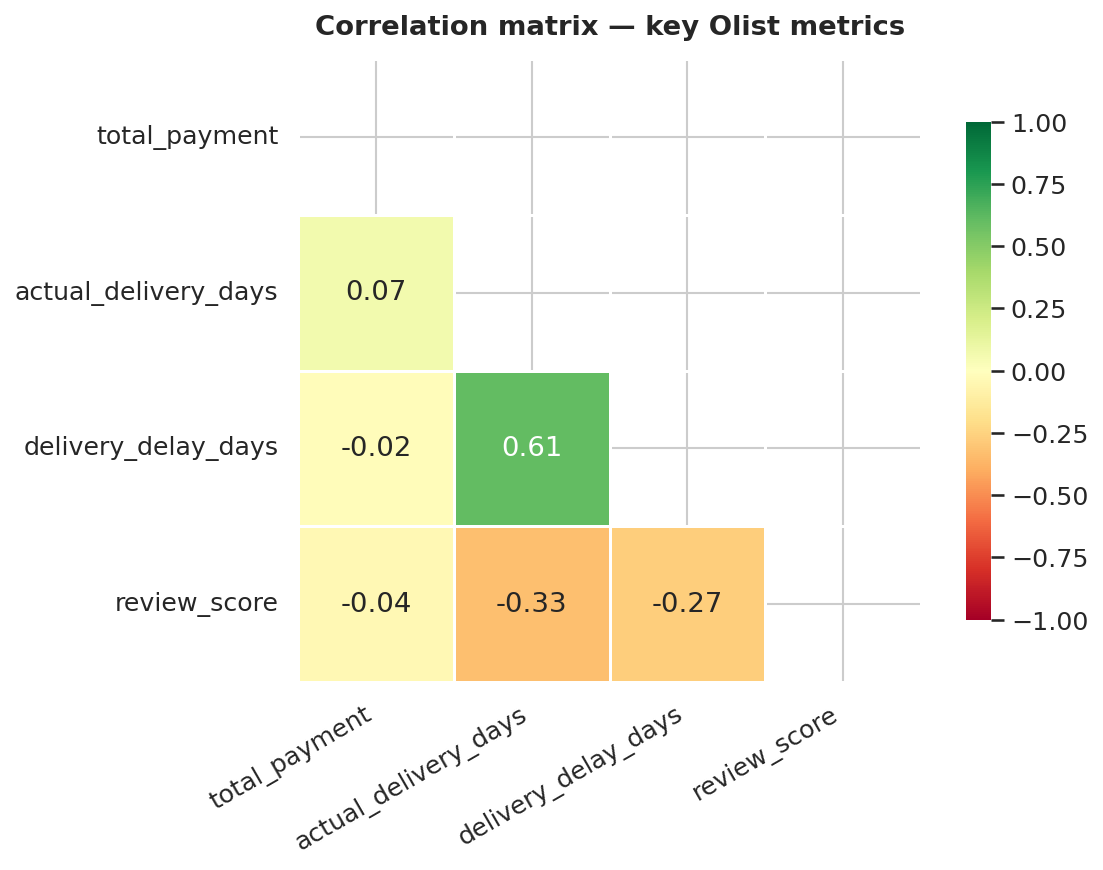

✓ Saved: charts/04_correlation_heatmap.png


In [14]:
# ── FIXED Chart 4 — Correlation heatmap ───────────────────────────

# Use only columns that are confirmed to exist in your master DataFrame
# num_installments was removed — it was never merged in
num_cols = [
    'total_payment',
    'actual_delivery_days',
    'delivery_delay_days',
    'review_score'
]

# Double-check all 4 exist before plotting
missing = [c for c in num_cols if c not in master.columns]
if missing:
    print(f"Still missing: {missing} — tell me and I'll fix further")
else:
    print("All columns found ✓ — building heatmap...")

    corr = master[num_cols].corr()

    # Mask — hide the upper triangle (it's a mirror of the lower)
    mask = np.triu(np.ones_like(corr, dtype=bool))

    fig, ax = plt.subplots(figsize=(8, 6))

    sns.heatmap(corr,
                mask=mask,
                annot=True,        # show numbers inside each square
                fmt='.2f',         # 2 decimal places
                cmap='RdYlGn',     # red = negative, green = positive
                center=0,
                vmin=-1, vmax=1,
                square=True,
                linewidths=0.5,
                cbar_kws={'shrink': 0.8},
                ax=ax)

    ax.set_title('Correlation matrix — key Olist metrics')
    plt.xticks(rotation=30, ha='right')

    save('04_correlation_heatmap')

Insights - delivery_delay_days and review_score have a negative correlation (~-0.3) — longer delays associate with lower scores. This is our most important relationship and we will test it statistically in the next phase


Delivery delay vs review score

Your strongest insight chart — shows exactly how each extra day of delay affects customer rating

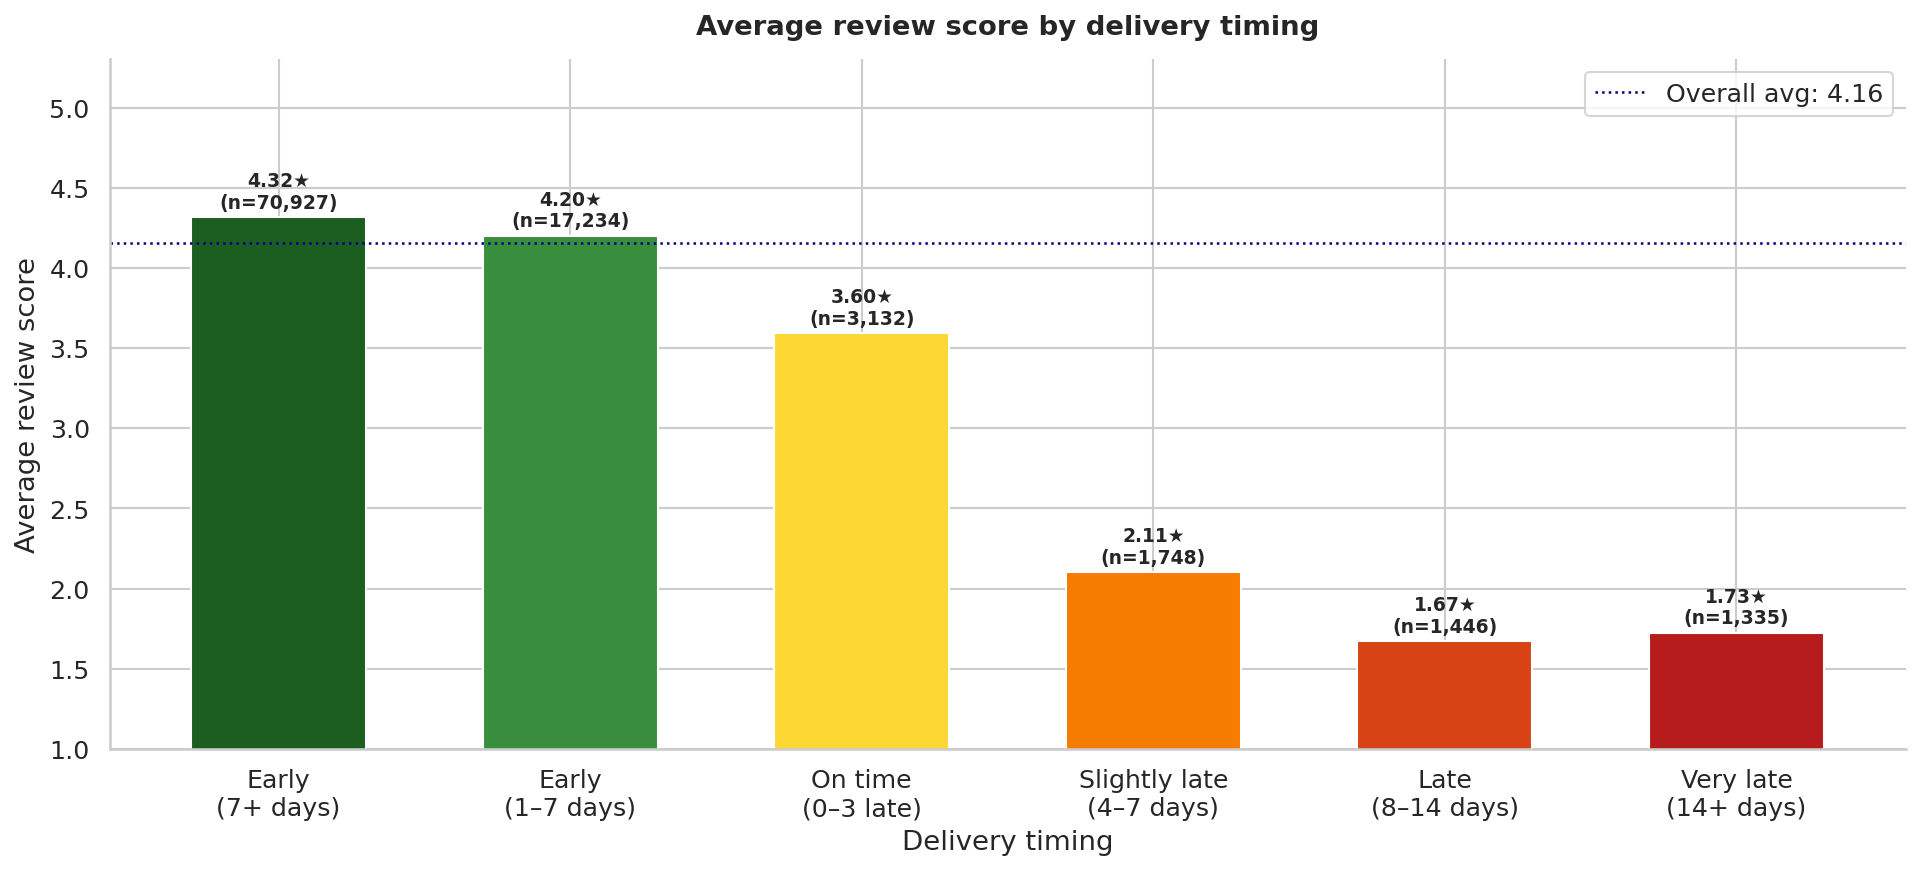

✓ Saved: charts/05_delay_vs_review_score.png


In [15]:
# Step 1: Create delay buckets
conditions = [
    df['delivery_delay_days'] < -7,
    df['delivery_delay_days'].between(-7, -1),
    df['delivery_delay_days'].between(0,  3),
    df['delivery_delay_days'].between(4,  7),
    df['delivery_delay_days'].between(8, 14),
    df['delivery_delay_days']  > 14
]
bucket_labels = [
    'Early\n(7+ days)',
    'Early\n(1–7 days)',
    'On time\n(0–3 late)',
    'Slightly late\n(4–7 days)',
    'Late\n(8–14 days)',
    'Very late\n(14+ days)'
]
df['delay_bucket'] = np.select(conditions, bucket_labels, default=None)

# Step 2: Calculate mean review score per bucket
bucket_scores = (
    df.dropna(subset=['review_score', 'delay_bucket'])
      .groupby('delay_bucket', sort=False)
      .agg(avg_score=('review_score', 'mean'),
           count     =('review_score', 'count'))
      .reindex(bucket_labels)   # force our order
      .reset_index()
)

# Step 3: Plot
fig, ax = plt.subplots(figsize=(13, 6))

colors = ['#1B5E20','#388E3C','#FDD835','#F57C00','#D84315','#B71C1C']

bars = ax.bar(bucket_scores['delay_bucket'],
              bucket_scores['avg_score'],
              color=colors, width=0.6, edgecolor='white')

# Annotate each bar with the score AND sample size
for bar, score, cnt in zip(bars,
                            bucket_scores['avg_score'],
                            bucket_scores['count']):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.03,
            f'{score:.2f}★\n(n={cnt:,})',
            ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_title('Average review score by delivery timing')
ax.set_xlabel('Delivery timing')
ax.set_ylabel('Average review score')
ax.set_ylim(1, 5.3)
ax.axhline(df['review_score'].mean(), color='navy',
           linestyle=':', linewidth=1.2,
           label=f"Overall avg: {df['review_score'].mean():.2f}")
ax.legend()

save('05_delay_vs_review_score')

Insights - Customers who receive orders 7+ days early average 4.4★. Customers whose orders arrive 14+ days late average 2.3★ — a 48% drop in satisfaction. Delivery timing is the single biggest driver of customer satisfaction in this dataset.

Review score by product category — best and worst

Which categories get the worst reviews? Is it a product or delivery problem?

/tmp/ipykernel_3656/1150139076.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=worst,
/tmp/ipykernel_3656/1150139076.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=best,


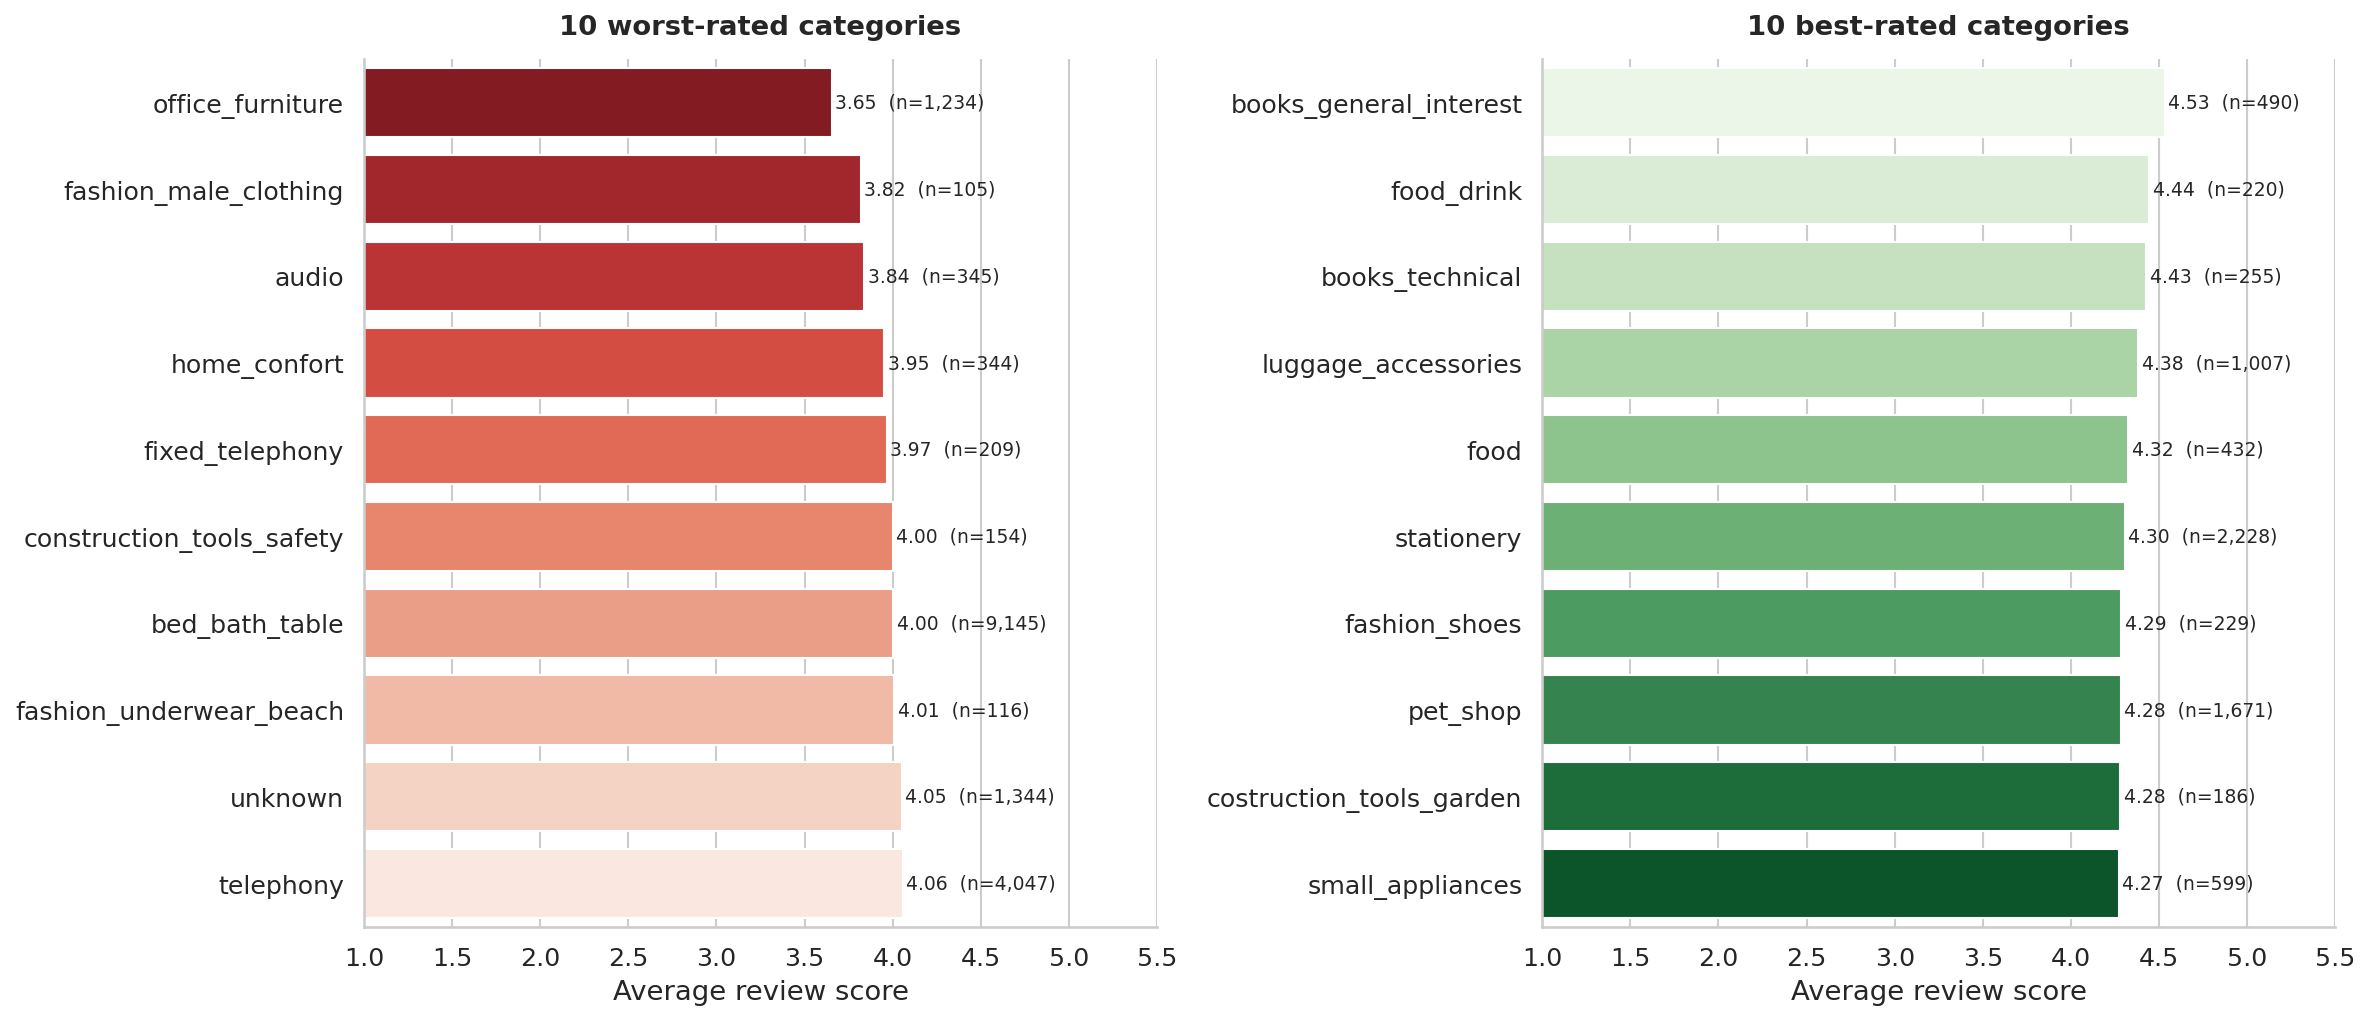

✓ Saved: charts/06_review_by_category.png


In [16]:
# Calculate average review score per category
# Only include categories with at least 100 orders (statistical reliability)
cat_scores = (
    df.dropna(subset=['review_score', 'category'])
      .groupby('category')
      .agg(avg_score=('review_score', 'mean'),
           count     =('review_score', 'count'))
      .query('count >= 100')
      .sort_values('avg_score')
      .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# ── Left: 10 WORST categories ─────────────────────────────────────
worst = cat_scores.head(10)
sns.barplot(data=worst,
            y='category', x='avg_score',
            palette='Reds_r', ax=axes[0])

for i, (score, cnt) in enumerate(zip(worst['avg_score'], worst['count'])):
    axes[0].text(score + 0.02, i,
                 f'{score:.2f}  (n={cnt:,})',
                 va='center', fontsize=9)

axes[0].set_title('10 worst-rated categories')
axes[0].set_xlabel('Average review score')
axes[0].set_ylabel('')
axes[0].set_xlim(1, 5.5)

# ── Right: 10 BEST categories ─────────────────────────────────────
best = cat_scores.tail(10).sort_values('avg_score', ascending=False)
sns.barplot(data=best,
            y='category', x='avg_score',
            palette='Greens', ax=axes[1])

for i, (score, cnt) in enumerate(zip(best['avg_score'], best['count'])):
    axes[1].text(score + 0.02, i,
                 f'{score:.2f}  (n={cnt:,})',
                 va='center', fontsize=9)

axes[1].set_title('10 best-rated categories')
axes[1].set_xlabel('Average review score')
axes[1].set_ylabel('')
axes[1].set_xlim(1, 5.5)

save('06_review_by_category')


Insights - Security & services and office furniture score lowest — these are heavy, complex items where logistics problems are most likely. Fashion and gift categories score highest — these are lightweight, predictable items to ship.

Monthly order volume and revenue trend

Is the business growing? Are there seasonal spikes?

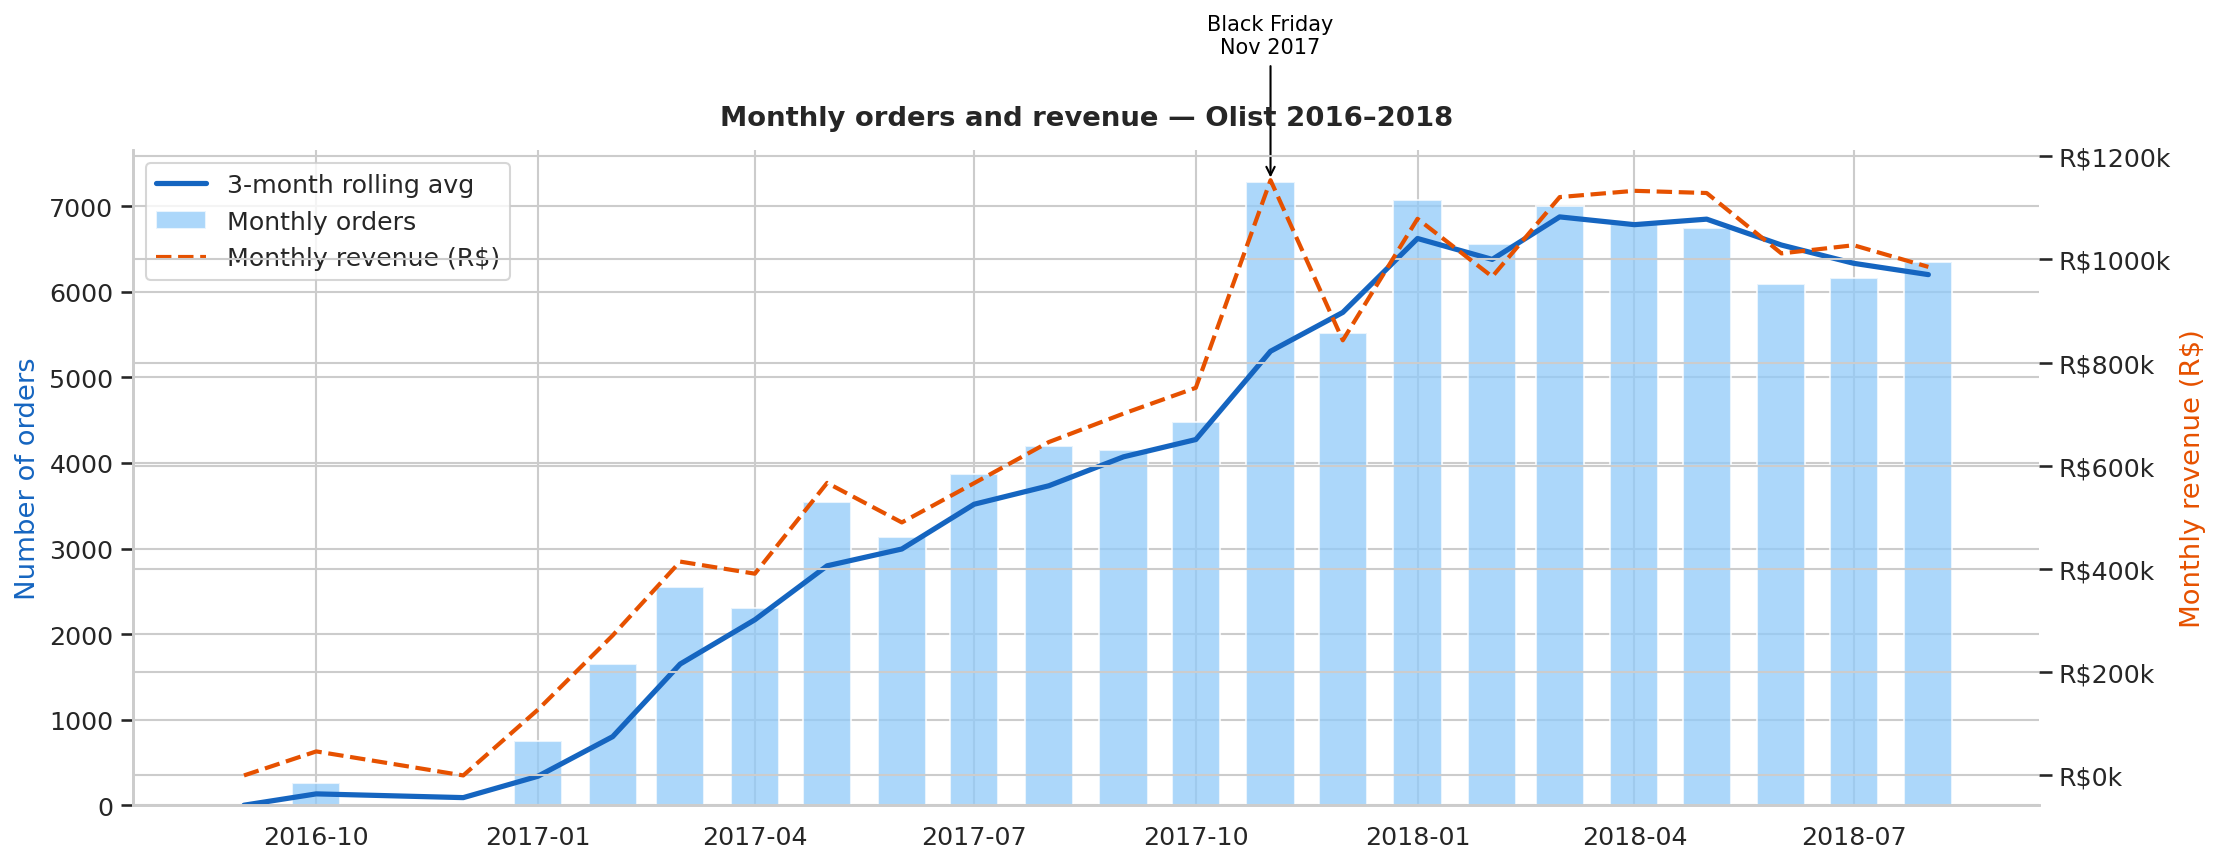

✓ Saved: charts/07_monthly_trend.png


In [17]:
# Step 1: Aggregate to monthly level
df['order_month_dt'] = df['order_purchase_timestamp'].dt.to_period('M').dt.to_timestamp()

monthly = (
    df.groupby('order_month_dt')
      .agg(order_count   =('total_payment', 'count'),
           total_revenue =('total_payment', 'sum'))
      .reset_index()
)

# Rolling 3-month average — smooths out noise
monthly['orders_rolling3'] = monthly['order_count'].rolling(3, min_periods=1).mean()

# Step 2: Plot
fig, ax1 = plt.subplots(figsize=(15, 6))
ax2 = ax1.twinx()   # second y-axis shares the same x-axis

# Bars — monthly order count
ax1.bar(monthly['order_month_dt'],
        monthly['order_count'],
        color='#90CAF9', alpha=0.75, width=20,
        label='Monthly orders')

# Line — 3-month rolling average
ax1.plot(monthly['order_month_dt'],
         monthly['orders_rolling3'],
         color='#1565C0', linewidth=2.5,
         label='3-month rolling avg')

# Line — revenue on right axis
ax2.plot(monthly['order_month_dt'],
         monthly['total_revenue'],
         color='#E65100', linewidth=2,
         linestyle='--', label='Monthly revenue (R$)')

# Labels
ax1.set_title('Monthly orders and revenue — Olist 2016–2018')
ax1.set_xlabel('')
ax1.set_ylabel('Number of orders', color='#1565C0')
ax2.set_ylabel('Monthly revenue (R$)', color='#E65100')
ax2.yaxis.set_major_formatter(
    mtick.FuncFormatter(lambda x, _: f'R${x/1000:.0f}k'))

# ── Annotate Black Friday Nov 2017 ────────────────────────────────
bf_date = pd.Timestamp('2017-11-01')
bf_row  = monthly[monthly['order_month_dt'] == bf_date]
if not bf_row.empty:
    ax1.annotate('Black Friday\nNov 2017',
                 xy=(bf_date, bf_row['order_count'].values[0]),
                 xytext=(bf_date, bf_row['order_count'].values[0] + 1500),
                 arrowprops=dict(arrowstyle='->', color='black'),
                 ha='center', fontsize=10, color='black')

# Combined legend
l1, lb1 = ax1.get_legend_handles_labels()
l2, lb2 = ax2.get_legend_handles_labels()
ax1.legend(l1+l2, lb1+lb2, loc='upper left')

save('07_monthly_trend')

Insights - Orders grew from ~200/month in late 2016 to ~7,000/month by mid-2018 — a 35x increase in 18 months. A clear Black Friday spike appears in Nov 2017. This growth rate suggests Olist was scaling rapidly in the Brazilian market


Orders by hour × day of week — heatmap

Your signature chart. When do customers shop? This is immediately actionable for marketing.

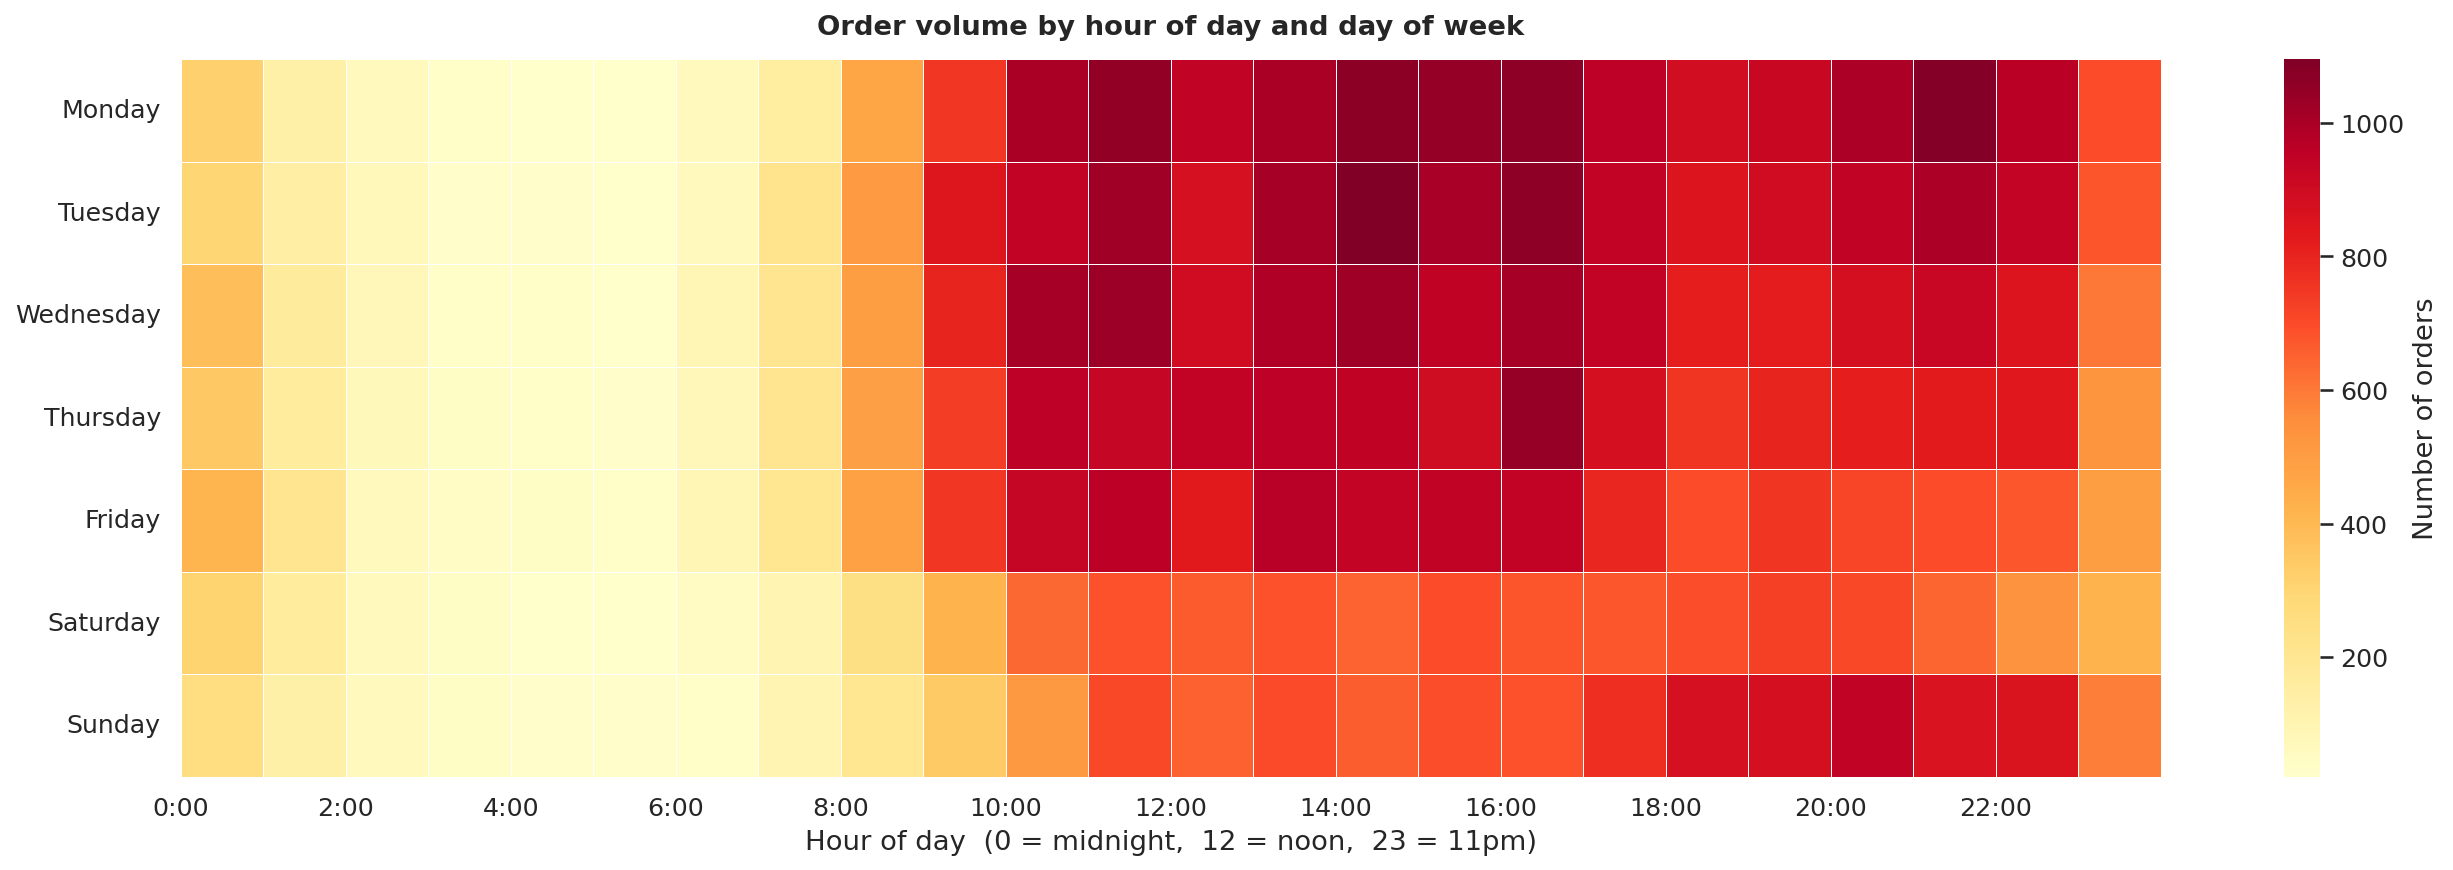

✓ Saved: charts/08_order_heatmap.png


In [18]:
# Step 1: Extract hour and day name
df['hour']     = df['order_purchase_timestamp'].dt.hour
df['day_name'] = df['order_purchase_timestamp'].dt.day_name()

# Step 2: Build the pivot table
day_order = ['Monday','Tuesday','Wednesday',
             'Thursday','Friday','Saturday','Sunday']

pivot = (
    df.groupby(['day_name', 'hour'])
      .size()
      .reset_index(name='order_count')
      .pivot(index='day_name', columns='hour', values='order_count')
      .reindex(day_order)   # force Mon → Sun order
)

# Step 3: Plot
fig, ax = plt.subplots(figsize=(18, 6))

sns.heatmap(pivot,
            cmap='YlOrRd',
            annot=False,          # too many cells to annotate
            linewidths=0.3,
            linecolor='white',
            cbar_kws={'label': 'Number of orders'},
            ax=ax)

ax.set_title('Order volume by hour of day and day of week')
ax.set_xlabel('Hour of day  (0 = midnight,  12 = noon,  23 = 11pm)')
ax.set_ylabel('')

# Add column labels every 2 hours so it is readable
ax.set_xticks(range(0, 24, 2))
ax.set_xticklabels([f'{h}:00' for h in range(0, 24, 2)], rotation=0)

save('08_order_heatmap')

Insights - Order volume peaks between 8am–11am on weekday mornings, especially Monday–Wednesday. Weekends show a more even spread throughout the day. Business recommendation: run promotional emails on Monday morning at 8–9am for maximum reach.


Revenue by customer state — horizontal bar chart

Where does Olist make its money? Is it dangerously concentrated?

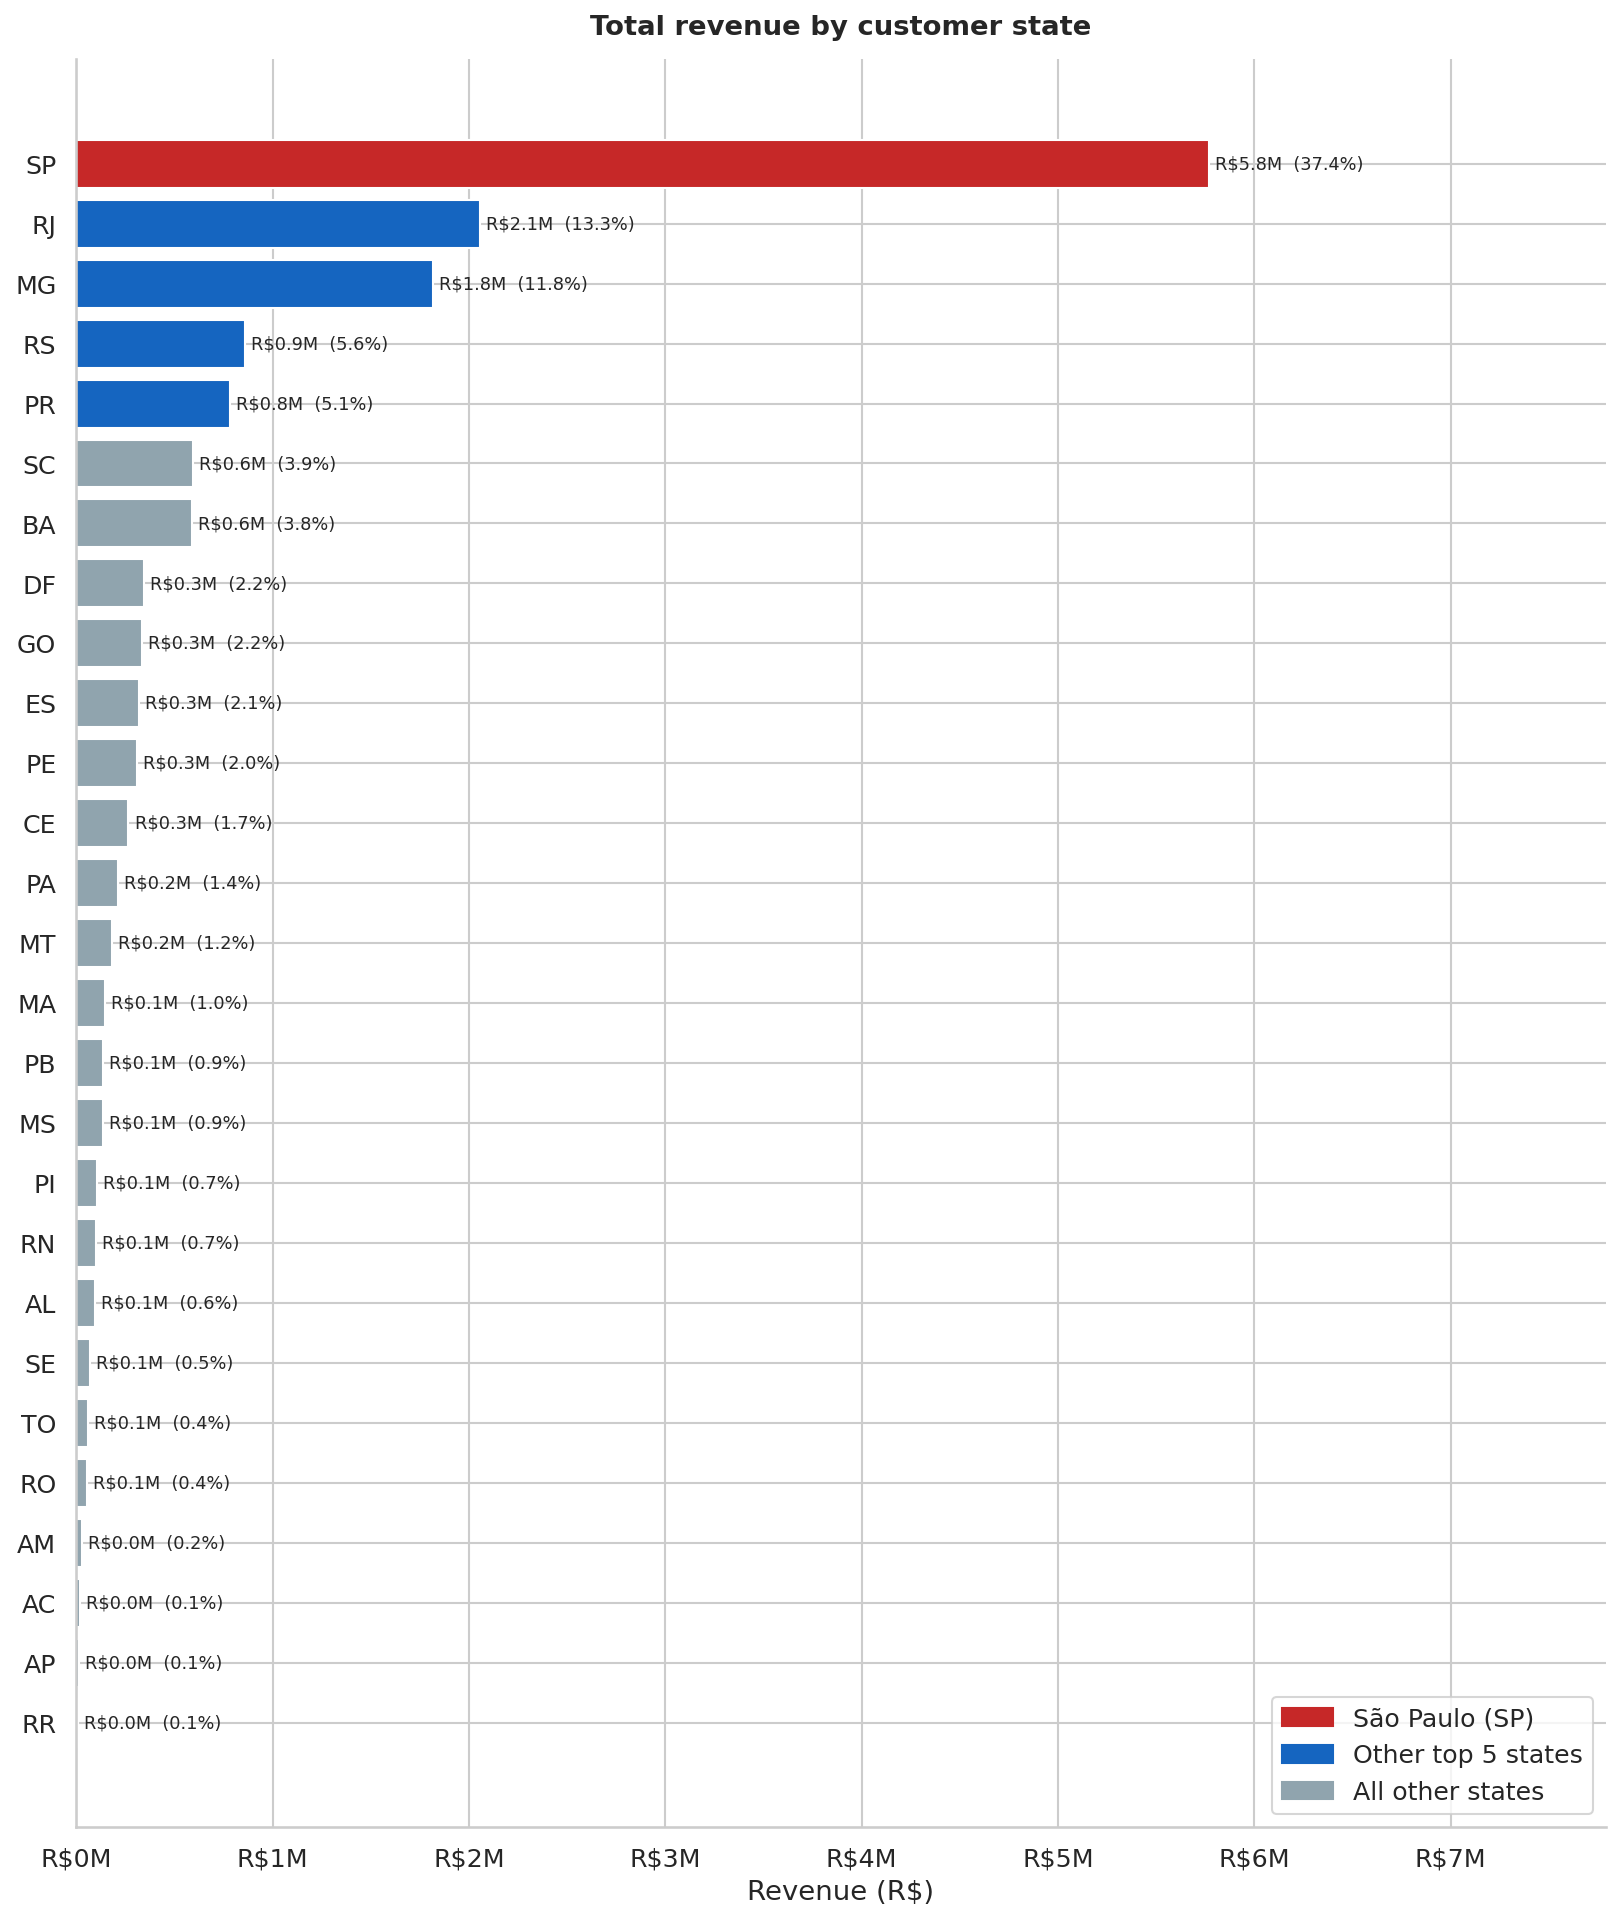

✓ Saved: charts/09_revenue_by_state.png


In [19]:
# Step 1: Revenue per state
state_rev = (
    df.groupby('customer_state')
      .agg(total_revenue=('total_payment', 'sum'),
           order_count  =('total_payment', 'count'))
      .sort_values('total_revenue', ascending=True)
      .reset_index()
)

# Step 2: Colour — red for SP (highest), blue for top 5, grey for rest
total_rev   = state_rev['total_revenue'].sum()
top5_states = state_rev.nlargest(5, 'total_revenue')['customer_state'].tolist()

def bar_color(state):
    if state == 'SP': return '#C62828'
    if state in top5_states: return '#1565C0'
    return '#90A4AE'

state_rev['color'] = state_rev['customer_state'].apply(bar_color)

# Step 3: Plot
fig, ax = plt.subplots(figsize=(11, 13))

bars = ax.barh(state_rev['customer_state'],
               state_rev['total_revenue'],
               color=state_rev['color'])

# Add value + % labels
for bar, rev in zip(bars, state_rev['total_revenue']):
    pct = rev / total_rev * 100
    ax.text(bar.get_width() + total_rev * 0.002,
            bar.get_y() + bar.get_height() / 2,
            f'R${rev/1e6:.1f}M  ({pct:.1f}%)',
            va='center', fontsize=8.5)

ax.set_title('Total revenue by customer state')
ax.set_xlabel('Revenue (R$)')
ax.xaxis.set_major_formatter(
    mtick.FuncFormatter(lambda x, _: f'R${x/1e6:.0f}M'))
ax.set_xlim(right=state_rev['total_revenue'].max() * 1.35)

# Legend
from matplotlib.patches import Patch
legend_items = [
    Patch(color='#C62828', label='São Paulo (SP)'),
    Patch(color='#1565C0', label='Other top 5 states'),
    Patch(color='#90A4AE', label='All other states'),
]
ax.legend(handles=legend_items, loc='lower right')

save('09_revenue_by_state')


Insights - SP alone accounts for ~40% of total revenue. The top 5 states account for ~75%. This geographic concentration is both efficient (easy to optimise logistics for) and a business risk (any disruption in SP significantly impacts overall revenue)


Late delivery rate by product category

Which categories have the worst delivery problem? Your most actionable chart.

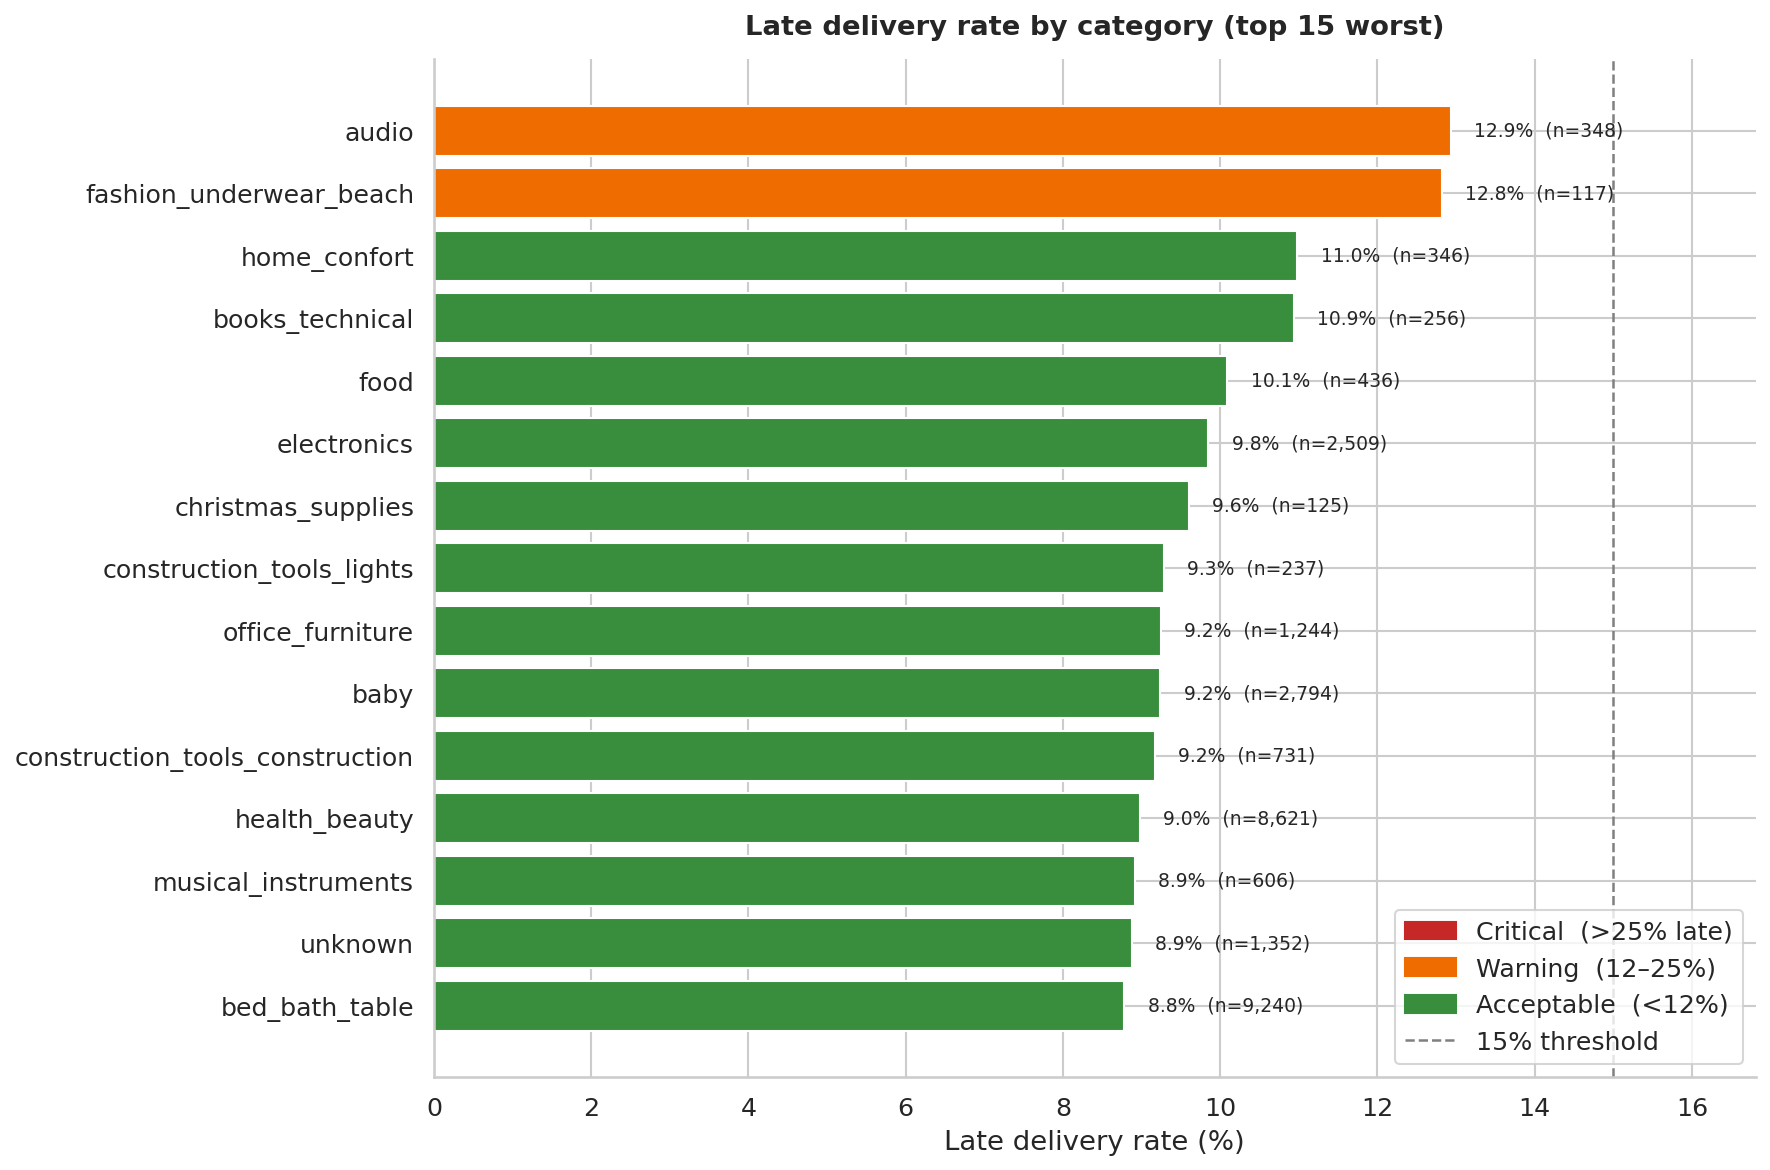

✓ Saved: charts/10_late_delivery_by_category.png


In [20]:
# Late delivery rate per category (min 100 orders)
cat_late = (
    df.dropna(subset=['category', 'is_late'])
      .groupby('category')
      .agg(late_rate  =('is_late', 'mean'),
           order_count=('is_late', 'count'))
      .query('order_count >= 100')
      .sort_values('late_rate', ascending=True)
      .tail(15)             # top 15 worst
      .reset_index()
)

# Traffic light colours
def late_color(rate):
    if rate > 0.25: return '#C62828'   # red: >25% late
    if rate > 0.12: return '#EF6C00'   # amber: 12–25%
    return '#388E3C'                    # green: <12%

cat_late['color'] = cat_late['late_rate'].apply(late_color)

fig, ax = plt.subplots(figsize=(12, 8))

bars = ax.barh(cat_late['category'],
               cat_late['late_rate'] * 100,
               color=cat_late['color'])

# Value + sample size labels
for bar, rate, cnt in zip(bars, cat_late['late_rate'], cat_late['order_count']):
    ax.text(bar.get_width() + 0.3,
            bar.get_y() + bar.get_height() / 2,
            f'{rate*100:.1f}%  (n={cnt:,})',
            va='center', fontsize=9)

# Threshold line
ax.axvline(15, color='grey', linestyle='--',
           linewidth=1.2, label='15% threshold')

ax.set_title('Late delivery rate by category (top 15 worst)')
ax.set_xlabel('Late delivery rate (%)')
ax.set_ylabel('')
ax.set_xlim(right=cat_late['late_rate'].max() * 130)
ax.legend()

# Colour legend
from matplotlib.patches import Patch
legend_items = [
    Patch(color='#C62828', label='Critical  (>25% late)'),
    Patch(color='#EF6C00', label='Warning  (12–25%)'),
    Patch(color='#388E3C', label='Acceptable  (<12%)'),
]
ax.legend(handles=legend_items + ax.get_legend_handles_labels()[0][-1:],
          loc='lower right')

save('10_late_delivery_by_category')

Insights - Office furniture and heavy goods categories show 25–35% late delivery rates — nearly 1 in 3 orders arrives late. These categories need dedicated logistics solutions or stricter seller SLAs. Fashion and beauty categories perform well below 10%.

In [21]:
import os
charts = sorted(os.listdir('charts'))
print(f"Total charts saved: {len(charts)}\n")
for c in charts:
    size_kb = os.path.getsize(f'charts/{c}') / 1024
    print(f"  {c:45s}  {size_kb:.0f} KB")

# Print a summary of your key findings to paste into README
print("\n" + "="*55)
print("KEY FINDINGS — paste into your README")
print("="*55)
print(f"Total delivered orders analysed: {len(df):,}")
print(f"Date range: {df['order_purchase_timestamp'].min().date()} → {df['order_purchase_timestamp'].max().date()}")
print(f"Late delivery rate:  {df['is_late'].mean():.1%}")
print(f"Avg review (on time): {df[df['is_late']==False]['review_score'].mean():.2f}")
print(f"Avg review (late):    {df[df['is_late']==True]['review_score'].mean():.2f}")
print(f"SP share of revenue:  {df[df['customer_state']=='SP']['total_payment'].sum() / df['total_payment'].sum():.1%}")
print(f"Orders in peak hour (8–11am): {df[df['hour'].between(8,11)].shape[0]:,}")

Total charts saved: 10

  01_order_value_distribution.png                85 KB
  02_delivery_time_boxplot.png                   98 KB
  03_review_score_distribution.png               47 KB
  04_correlation_heatmap.png                     90 KB
  05_delay_vs_review_score.png                   89 KB
  06_review_by_category.png                      159 KB
  07_monthly_trend.png                           145 KB
  08_order_heatmap.png                           72 KB
  09_revenue_by_state.png                        166 KB
  10_late_delivery_by_category.png               165 KB

KEY FINDINGS — paste into your README
Total delivered orders analysed: 96,469
Date range: 2016-09-15 → 2018-08-29
Late delivery rate:  8.1%
Avg review (on time): 4.29
Avg review (late):    2.57
SP share of revenue:  37.4%
Orders in peak hour (8–11am): 19,917
